# Day21 Model Interpretability

本 notebook 用于展示 Day21 模型解释性分析。边界：只复现 Day14 final candidate 用于解释，不调参、不重新选择 threshold、不修改 `data/raw/`，也不解释匿名字段的真实物理含义。

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT / 'src'))

TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables' / 'final'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures' / 'final'
REPORT_DIR = PROJECT_ROOT / 'reports'

TABLE_DIR, FIGURE_DIR, REPORT_DIR

(WindowsPath('c:/Scania APS/outputs/tables/final'),
 WindowsPath('c:/Scania APS/outputs/figures/final'),
 WindowsPath('c:/Scania APS/reports'))

## 1. 读取 cfg 并复现 final candidate

如果需要重新生成 Day21 输出，请在项目根目录运行：

```powershell
python scripts/19_model_interpretability.py
```

该脚本会复现 Day14 `median_all_structural_all`，并校验 official test FP/FN/total_cost 是否为 398 / 12 / 9980。

In [2]:
day14 = pd.read_csv(PROJECT_ROOT / 'outputs' / 'metrics' / 'day14_structural_feature_test_results.csv')
final_row = day14.loc[day14['strategy'].eq('median_all_structural_all')]
display(final_row[['strategy', 'threshold', 'fp', 'fn', 'tp', 'tn', 'total_cost', 'average_precision']])

,strategy,threshold,fp,fn,tp,tn,total_cost,average_precision
0,median_all_structural_all,0.18,398,12,363,15227,9980,0.905455


## 2. XGBoost feature importance

,feature_name,feature_family,importance_weight,importance_gain,importance_cover,rank_by_gain
0,ck_000,raw_feature,96.0,5084.788574,4933.823242,1
1,aa_000,raw_feature,119.0,1528.003052,2776.235596,2
2,ci_000,raw_feature,54.0,1385.818604,3335.987061,3
3,ba_002,raw_feature,15.0,653.802124,4059.025879,4
4,cs_002,raw_feature,30.0,495.859436,2868.861816,5
5,cc_000,raw_feature,22.0,356.566132,2279.976807,6
6,dn_000,raw_feature,24.0,343.274872,1542.647339,7
7,az_000,raw_feature,27.0,267.318298,2172.544189,8
8,prefix_cn_zero_rate,prefix_zero_feature,2.0,222.013000,2084.222168,9
9,missing_br_000,missing_indicator,2.0,209.803635,192.128265,10


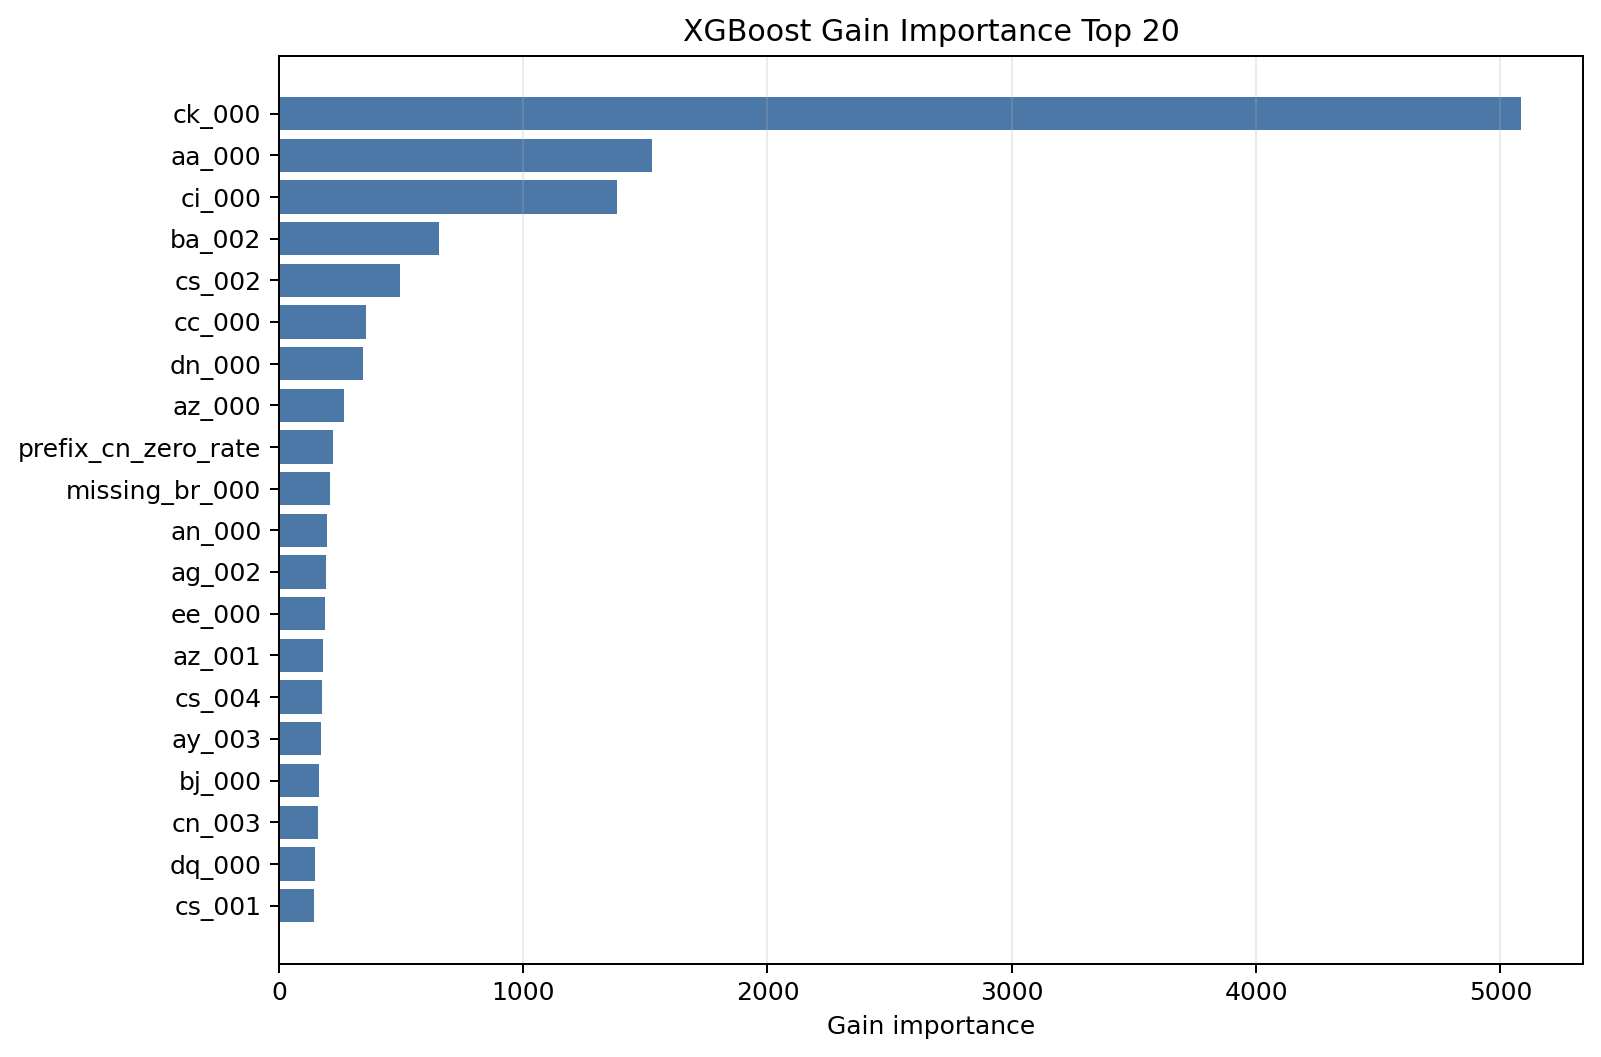

In [3]:
xgb_importance = pd.read_csv(TABLE_DIR / 'final_xgb_feature_importance_top50.csv')
display(xgb_importance.head(20))
display(Image(filename=str(FIGURE_DIR / 'final_xgb_gain_importance_top20.png')))

## 3. Permutation importance

Permutation importance 只用于解释模型对特征扰动的敏感性，不用于筛特征或改模型。

,feature_name,feature_family,baseline_average_precision,permuted_average_precision,average_precision_drop,baseline_f2,permuted_f2,f2_drop,baseline_total_cost,permuted_total_cost,total_cost_increase,candidate_rank_by_gain,rank
0,ag_002,raw_feature,0.926377,0.902078,0.024299,0.827586,0.825581,0.002005,750,1210,460,12,1
1,ck_000,raw_feature,0.926377,0.916739,0.009638,0.827586,0.845588,-0.018002,750,2010,1260,1,2
2,aa_000,raw_feature,0.926377,0.918142,0.008235,0.827586,0.839506,-0.011920,750,2490,1740,2,3
3,bx_000,raw_feature,0.926377,0.921176,0.005201,0.827586,0.825581,0.002005,750,1210,460,22,4
4,bj_000,raw_feature,0.926377,0.922703,0.003674,0.827586,0.833333,-0.005747,750,1170,420,17,5
5,cc_000,raw_feature,0.926377,0.923214,0.003164,0.827586,0.837209,-0.009623,750,700,-50,6,6
6,cn_000,raw_feature,0.926377,0.923294,0.003083,0.827586,0.829493,-0.001907,750,740,-10,27,7
7,dq_000,raw_feature,0.926377,0.923801,0.002576,0.827586,0.810811,0.016775,750,840,90,19,8
8,ci_000,raw_feature,0.926377,0.924241,0.002136,0.827586,0.843521,-0.015935,750,2020,1270,3,9
9,do_000,raw_feature,0.926377,0.924446,0.001931,0.827586,0.833333,-0.005747,750,720,-30,28,10


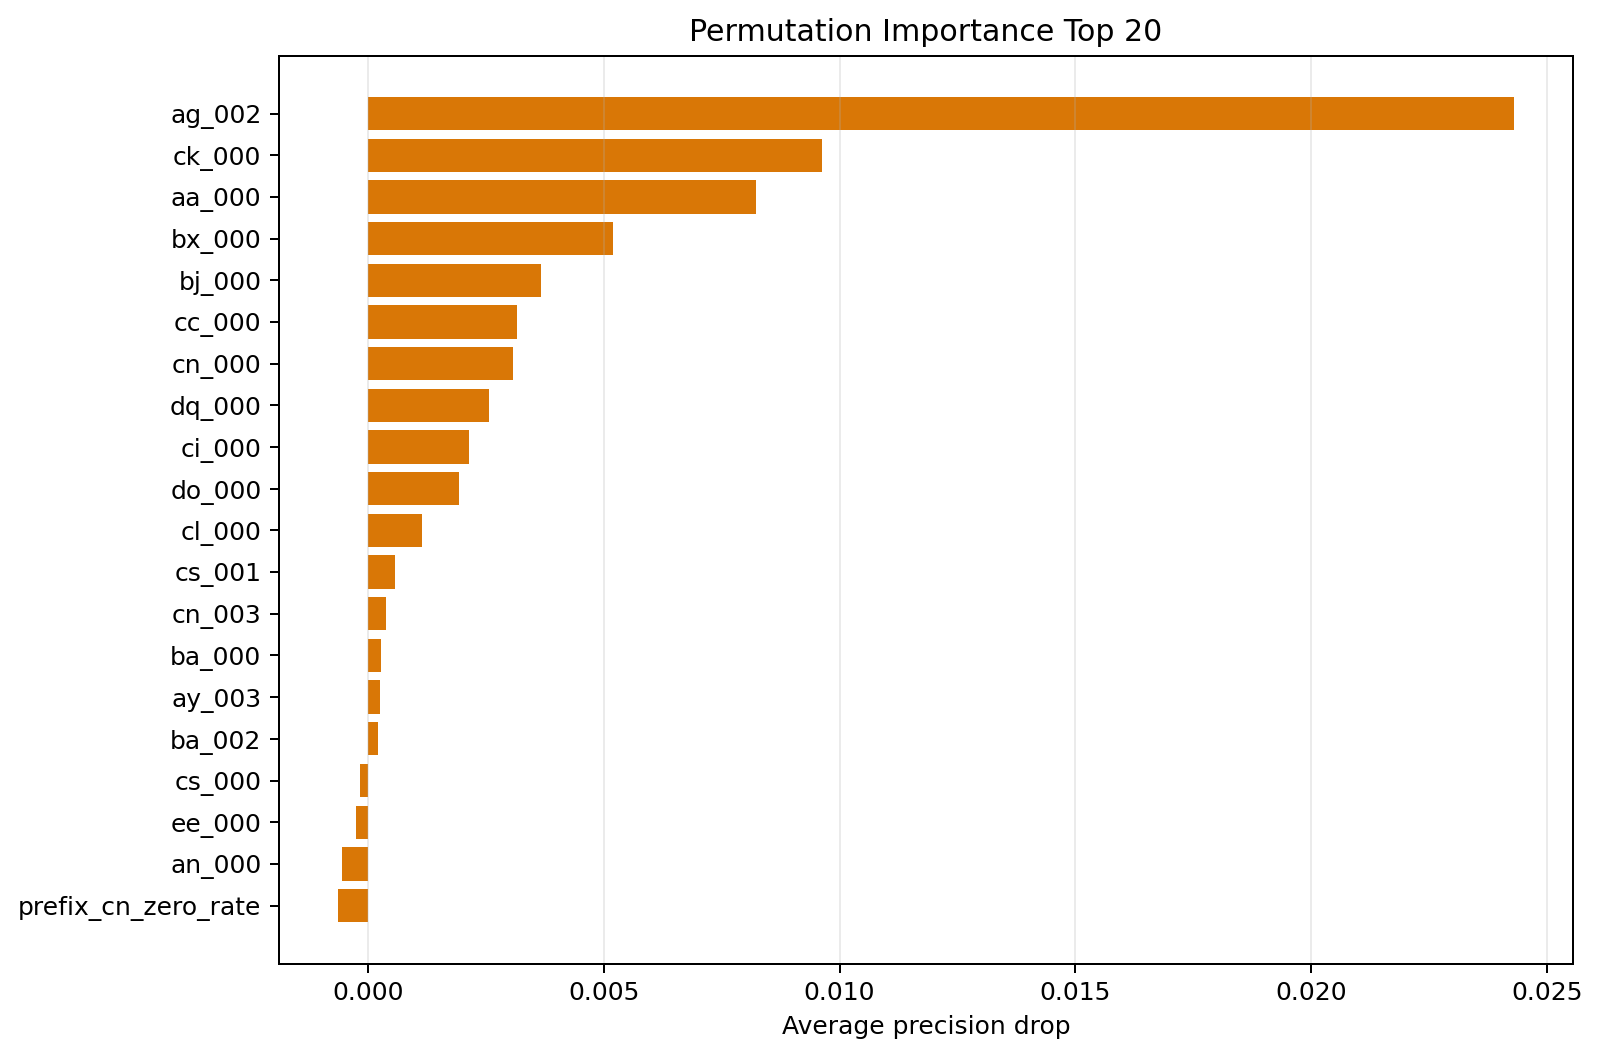

In [4]:
permutation_importance = pd.read_csv(TABLE_DIR / 'final_permutation_importance_top30.csv')
display(permutation_importance.head(20))
display(Image(filename=str(FIGURE_DIR / 'final_permutation_importance_top20.png')))

## 4. SHAP global summary

SHAP 解释模型评分贡献，不解释匿名字段真实物理含义。

,feature_name,feature_family,mean_abs_shap,rank,direction_note
0,aa_000,raw_feature,1.188662,1,正负方向需结合样本级 SHAP 和特征值查看；不解释真实物理含义。
1,ck_000,raw_feature,1.011456,2,正负方向需结合样本级 SHAP 和特征值查看；不解释真实物理含义。
2,ci_000,raw_feature,0.416530,3,正负方向需结合样本级 SHAP 和特征值查看；不解释真实物理含义。
3,ay_008,raw_feature,0.258737,4,正负方向需结合样本级 SHAP 和特征值查看；不解释真实物理含义。
4,ai_000,raw_feature,0.253018,5,正负方向需结合样本级 SHAP 和特征值查看；不解释真实物理含义。
5,cc_000,raw_feature,0.249429,6,正负方向需结合样本级 SHAP 和特征值查看；不解释真实物理含义。
6,ay_006,raw_feature,0.234987,7,正负方向需结合样本级 SHAP 和特征值查看；不解释真实物理含义。
7,aq_000,raw_feature,0.205695,8,正负方向需结合样本级 SHAP 和特征值查看；不解释真实物理含义。
8,cb_000,raw_feature,0.202688,9,正负方向需结合样本级 SHAP 和特征值查看；不解释真实物理含义。
9,bi_000,raw_feature,0.195212,10,正负方向需结合样本级 SHAP 和特征值查看；不解释真实物理含义。


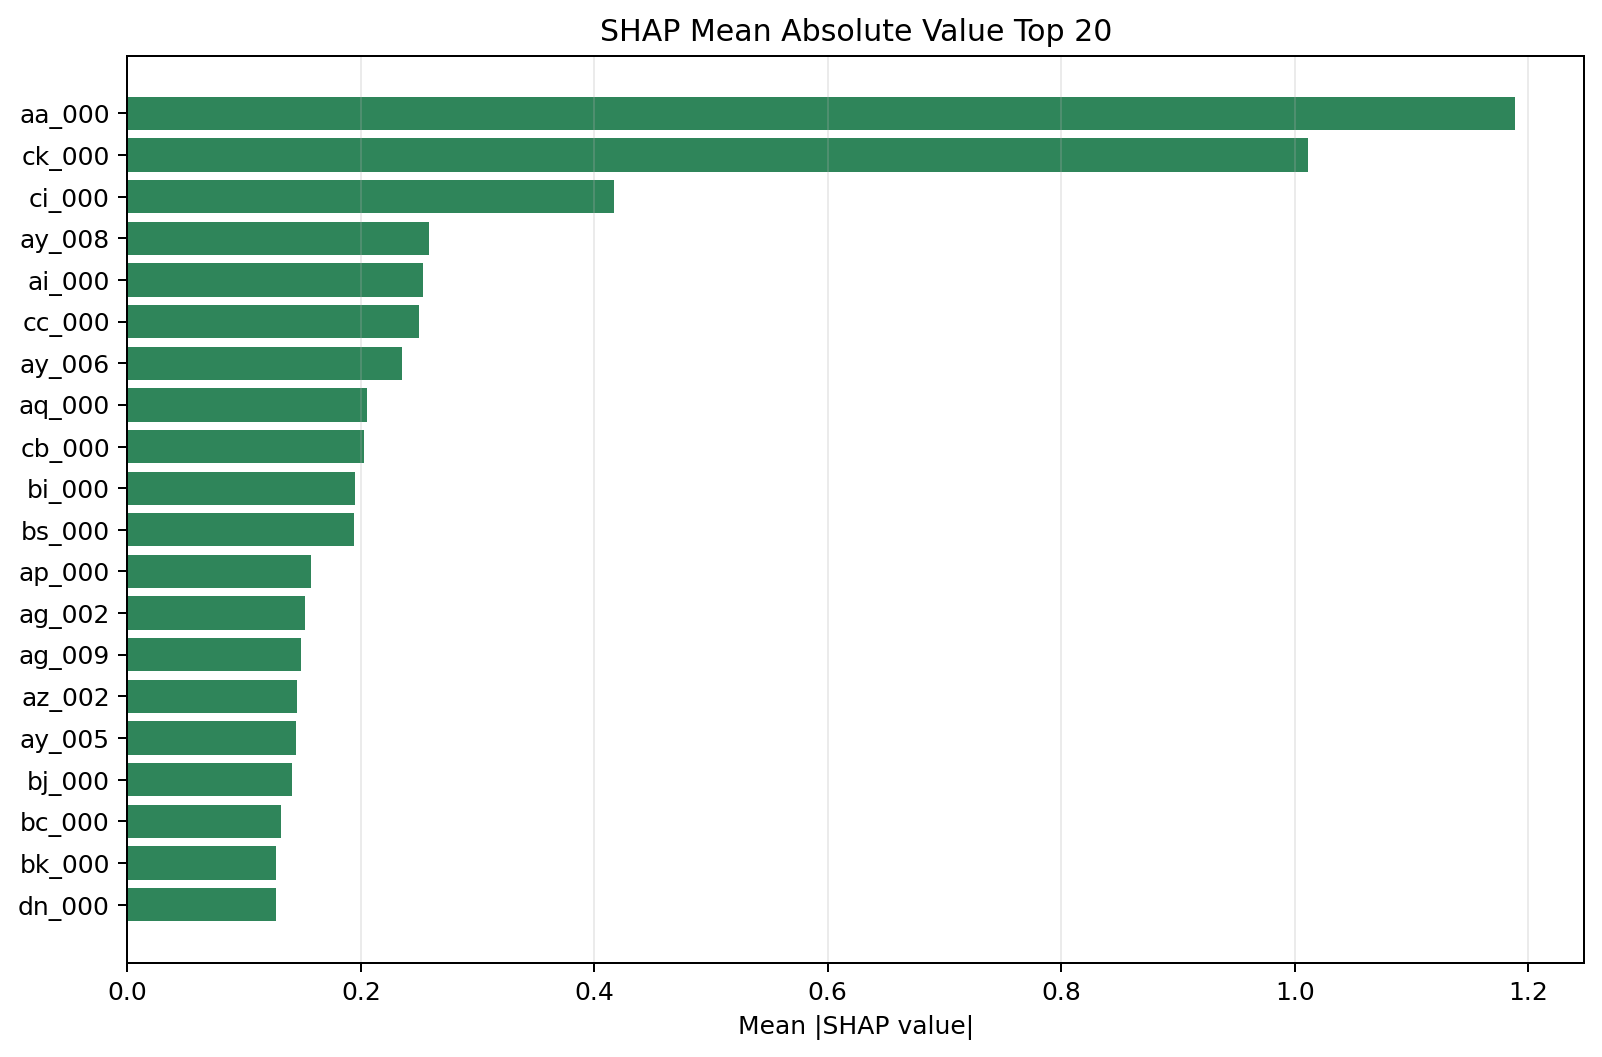

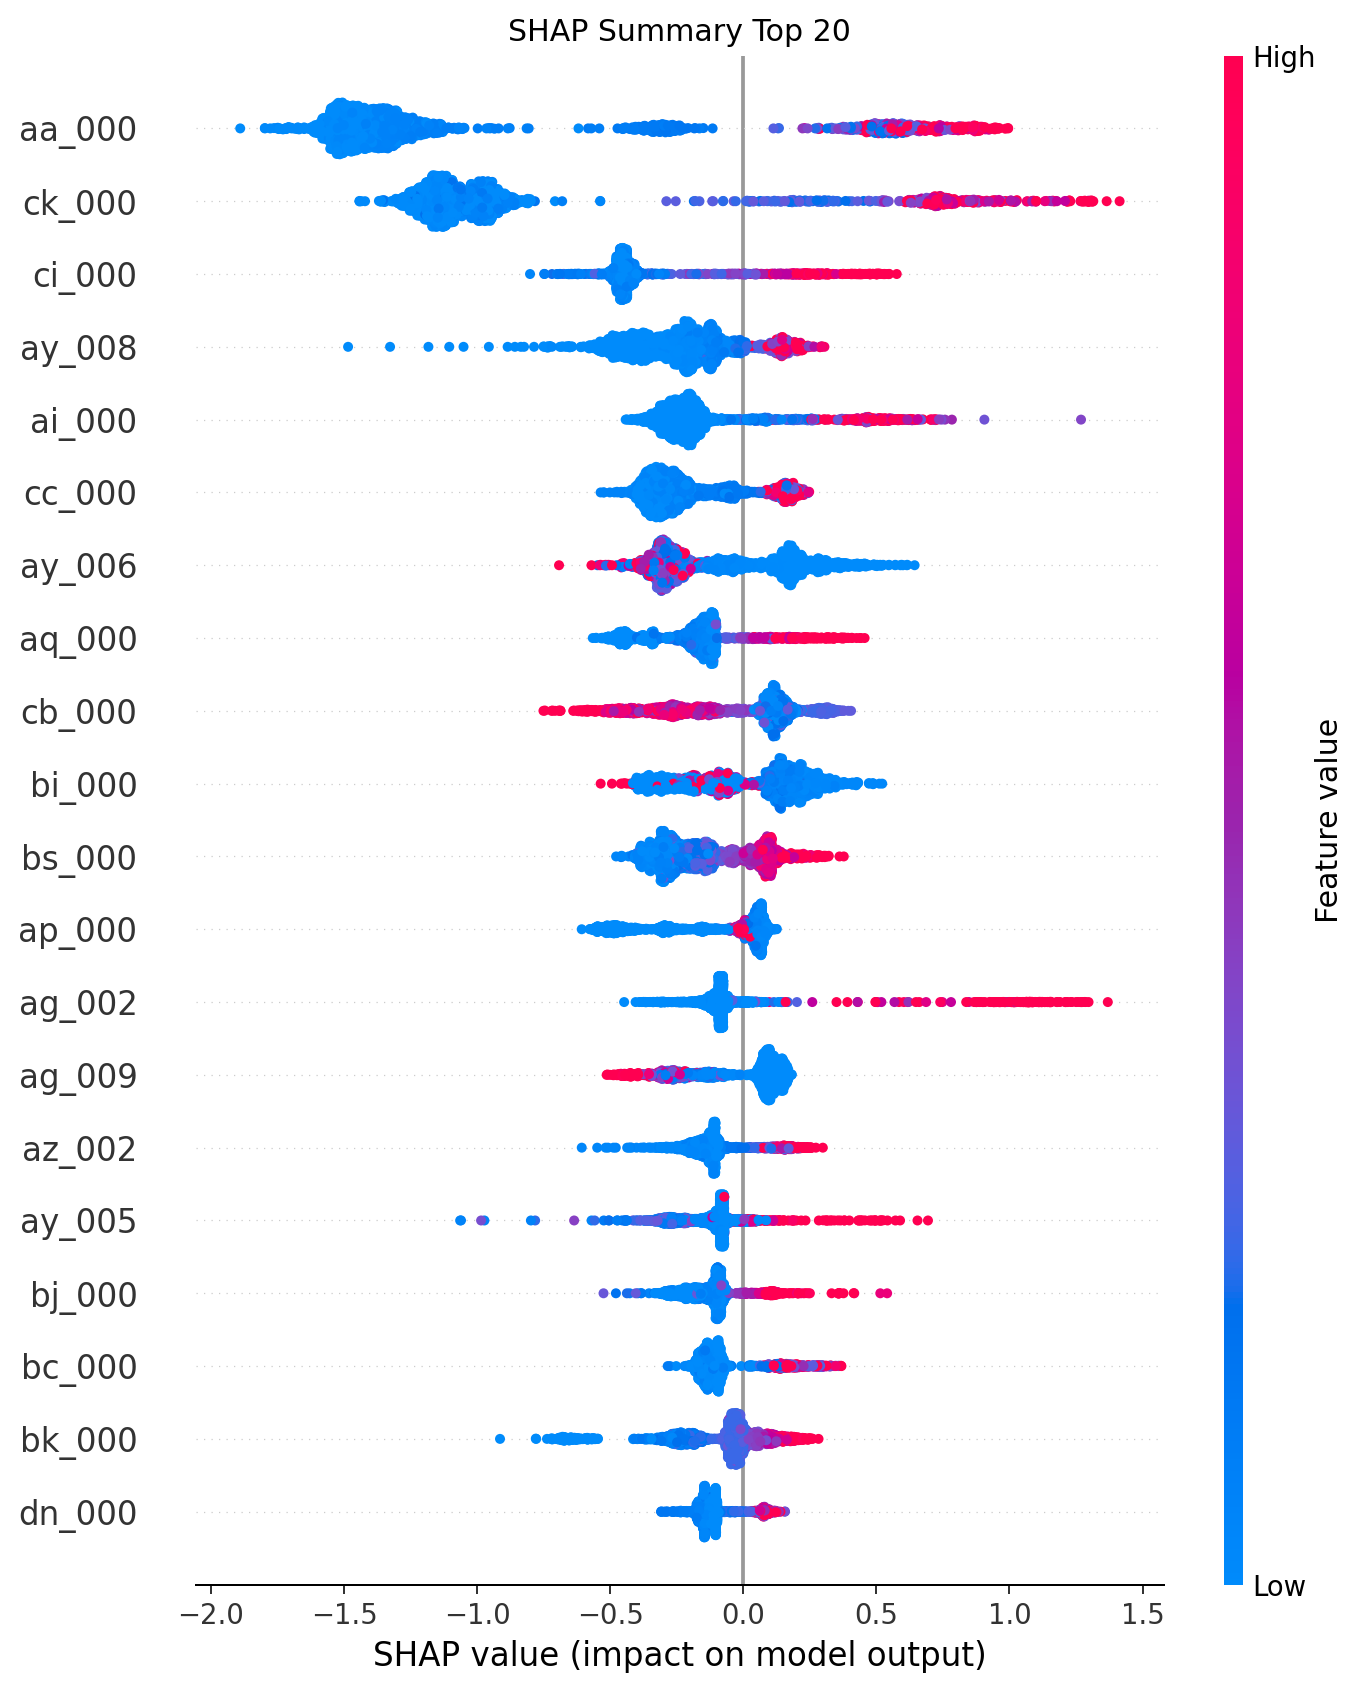

In [5]:
shap_importance = pd.read_csv(TABLE_DIR / 'final_shap_mean_abs_top50.csv')
display(shap_importance.head(20))
display(Image(filename=str(FIGURE_DIR / 'final_shap_bar_top20.png')))
display(Image(filename=str(FIGURE_DIR / 'final_shap_summary_top20.png')))

## 5. Feature family importance

,feature_family,feature_count,xgb_gain_total,xgb_gain_share,mean_abs_shap_total,mean_abs_shap_share,permutation_ap_drop_total
0,raw_feature,168,20049.283424,0.929174,10.091125,0.960736,0.066792
1,sample_structural_feature,6,374.425121,0.017353,0.168039,0.015998,NaN
2,prefix_zero_feature,10,637.611670,0.029550,0.137927,0.013131,0.000000
3,unknown,2,178.561188,0.008275,0.081378,0.007748,NaN
4,missing_indicator,30,337.656870,0.015649,0.025068,0.002387,0.000000
5,prefix_missing_feature,14,0.000000,0.000000,0.000000,0.000000,NaN


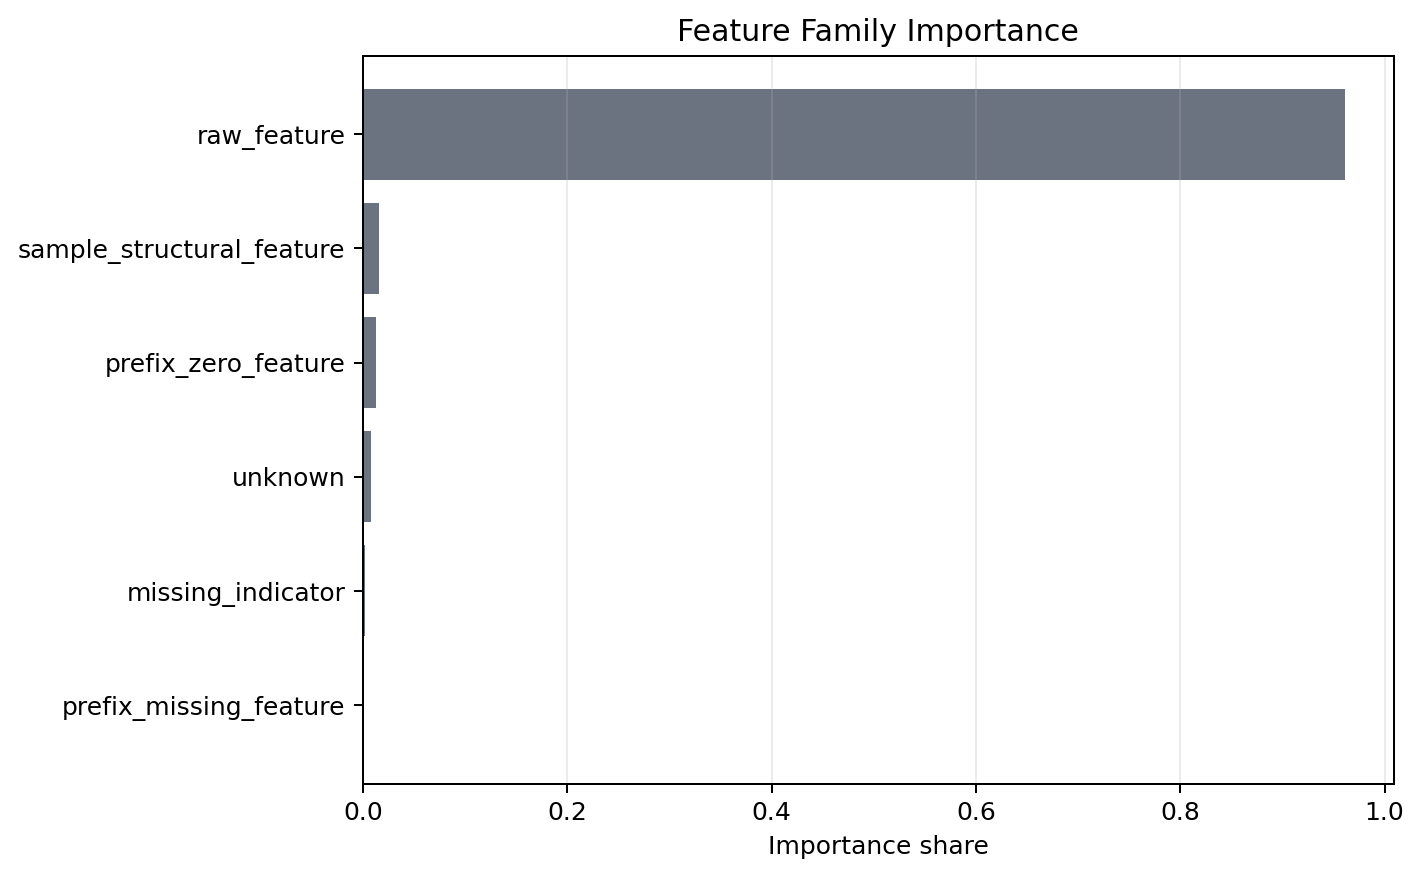

In [6]:
family_summary = pd.read_csv(TABLE_DIR / 'final_feature_family_importance_summary.csv')
display(family_summary)
display(Image(filename=str(FIGURE_DIR / 'final_feature_family_importance.png')))

## 6. FN / FP / TP case explanation

In [7]:
fn_cases = pd.read_csv(TABLE_DIR / 'final_fn_shap_case_analysis.csv')
tp_cases = pd.read_csv(TABLE_DIR / 'final_high_risk_tp_shap_case_analysis.csv')
fp_cases = pd.read_csv(TABLE_DIR / 'final_high_confidence_fp_shap_case_analysis.csv')

display(fn_cases.head(10))
display(tp_cases.head(10))
display(fp_cases.head(10))

,sample_id,y_true,y_pred,y_proba,risk_level,top_positive_shap_features,top_negative_shap_features,note
0,470,1,0,0.150951,Medium,ag_002: 0.6182; aa_000: 0.4806; cs_002: 0.4685...,ck_000: -0.9054; ay_005: -0.5703; bk_000: -0.3...,FN 样本：模型评分未超过固定阈值 0.18，需人工复核漏报风险。
1,903,1,0,0.120458,Medium,aa_000: 0.6582; ck_000: 0.2326; cc_000: 0.1906...,ay_005: -0.3861; ai_000: -0.2676; ay_006: -0.2...,FN 样本：模型评分未超过固定阈值 0.18，需人工复核漏报风险。
2,8362,1,0,0.099746,Medium,aa_000: 0.6904; ba_002: 0.2475; cs_002: 0.2112...,ck_000: -1.1170; ay_008: -0.3863; bk_000: -0.3...,FN 样本：模型评分未超过固定阈值 0.18，需人工复核漏报风险。
3,14497,1,0,0.091330,Medium,aa_000: 0.8962; ao_000: 0.3201; ay_005: 0.3004...,ay_008: -0.8855; bk_000: -0.7377; bs_000: -0.3...,FN 样本：模型评分未超过固定阈值 0.18，需人工复核漏报风险。
4,6282,1,0,0.089807,Medium,ck_000: 0.8596; aa_000: 0.6083; ai_000: 0.3535...,ag_009: -0.4749; ay_008: -0.4161; ay_006: -0.3...,FN 样本：模型评分未超过固定阈值 0.18，需人工复核漏报风险。
5,9195,1,0,0.079623,Medium,ck_000: 1.1678; aa_000: 0.6860; cs_002: 0.1459...,ay_008: -0.7488; cb_000: -0.4709; ai_000: -0.4...,FN 样本：模型评分未超过固定阈值 0.18，需人工复核漏报风险。
6,7939,1,0,0.054730,Medium,aa_000: 0.2877; cs_002: 0.1971; ai_000: 0.1828...,ee_007: -0.7781; dq_000: -0.5116; ag_002: -0.3...,FN 样本：模型评分未超过固定阈值 0.18，需人工复核漏报风险。
7,5072,1,0,0.043660,Low,bk_000: 0.2440; cl_000: 0.2303; cs_002: 0.2252...,ci_000: -0.5091; dy_000: -0.4459; ay_006: -0.4...,FN 样本：模型评分未超过固定阈值 0.18，需人工复核漏报风险。
8,15606,1,0,0.042122,Low,prefix_ay_zero_count: 0.5494; ay_002: 0.3551; ...,aa_000: -1.1850; ck_000: -0.9810; ci_000: -0.5...,FN 样本：模型评分未超过固定阈值 0.18，需人工复核漏报风险。
9,429,1,0,0.030028,Low,cl_000: 0.3515; ay_006: 0.3497; ao_000: 0.2308...,aa_000: -1.2337; ck_000: -1.1321; ci_000: -0.4...,FN 样本：模型评分未超过固定阈值 0.18，需人工复核漏报风险。


,sample_id,y_true,y_pred,y_proba,risk_level,top_positive_shap_features,top_negative_shap_features,note
0,9397,1,1,0.999726,Critical,ag_002: 0.9737; ck_000: 0.7492; aa_000: 0.7366...,NaN,高风险 TP 样本：这些特征在模型评分层面推高风险。
1,11829,1,1,0.999667,Critical,ag_002: 0.9074; aa_000: 0.7348; ck_000: 0.7277...,NaN,高风险 TP 样本：这些特征在模型评分层面推高风险。
2,4406,1,1,0.999655,Critical,ag_002: 0.9927; ck_000: 0.7036; aa_000: 0.6158...,NaN,高风险 TP 样本：这些特征在模型评分层面推高风险。
3,15299,1,1,0.999654,Critical,ag_002: 0.9252; ck_000: 0.7144; aa_000: 0.5810...,NaN,高风险 TP 样本：这些特征在模型评分层面推高风险。
4,9796,1,1,0.999639,Critical,ag_002: 1.1510; ck_000: 0.7243; aa_000: 0.6803...,NaN,高风险 TP 样本：这些特征在模型评分层面推高风险。
5,3582,1,1,0.999544,Critical,ag_002: 0.9603; ck_000: 0.7459; aa_000: 0.6290...,NaN,高风险 TP 样本：这些特征在模型评分层面推高风险。
6,3337,1,1,0.999537,Critical,ag_002: 1.2309; aa_000: 0.8618; ag_001: 0.5191...,NaN,高风险 TP 样本：这些特征在模型评分层面推高风险。
7,6160,1,1,0.999506,Critical,ag_002: 1.0150; ck_000: 0.7426; ag_001: 0.6191...,NaN,高风险 TP 样本：这些特征在模型评分层面推高风险。
8,9323,1,1,0.999479,Critical,ag_002: 0.8753; ck_000: 0.7196; aa_000: 0.6891...,NaN,高风险 TP 样本：这些特征在模型评分层面推高风险。
9,9197,1,1,0.999456,Critical,ag_002: 1.2713; ck_000: 0.7775; ag_001: 0.7696...,NaN,高风险 TP 样本：这些特征在模型评分层面推高风险。


,sample_id,y_true,y_pred,y_proba,risk_level,top_positive_shap_features,top_negative_shap_features,note
0,11621,0,1,0.995038,Critical,ck_000: 0.8571; aa_000: 0.7740; ay_005: 0.5889...,NaN,高置信 FP 样本：模型评分被推高，但真实标签为 neg；不代表真实车辆故障。
1,14218,0,1,0.992693,Critical,ck_000: 0.6415; prefix_ay_zero_count: 0.5648; ...,NaN,高置信 FP 样本：模型评分被推高，但真实标签为 neg；不代表真实车辆故障。
2,4718,0,1,0.992577,Critical,ck_000: 0.9659; aa_000: 0.9278; ay_005: 0.6938...,NaN,高置信 FP 样本：模型评分被推高，但真实标签为 neg；不代表真实车辆故障。
3,5106,0,1,0.991123,Critical,aa_000: 0.8727; ck_000: 0.7756; ay_005: 0.5163...,NaN,高置信 FP 样本：模型评分被推高，但真实标签为 neg；不代表真实车辆故障。
4,1430,0,1,0.990067,Critical,aa_000: 0.8709; ck_000: 0.8241; ay_005: 0.6544...,NaN,高置信 FP 样本：模型评分被推高，但真实标签为 neg；不代表真实车辆故障。
5,13857,0,1,0.989620,Critical,aa_000: 0.8079; ck_000: 0.7044; ai_000: 0.5379...,NaN,高置信 FP 样本：模型评分被推高，但真实标签为 neg；不代表真实车辆故障。
6,4974,0,1,0.982898,Critical,aa_000: 0.8438; ck_000: 0.7933; ai_000: 0.6150...,NaN,高置信 FP 样本：模型评分被推高，但真实标签为 neg；不代表真实车辆故障。
7,5085,0,1,0.981127,Critical,ck_000: 1.2243; aa_000: 0.8223; ai_000: 0.6233...,NaN,高置信 FP 样本：模型评分被推高，但真实标签为 neg；不代表真实车辆故障。
8,971,0,1,0.978337,Critical,aa_000: 0.8808; ck_000: 0.7504; ai_000: 0.5942...,NaN,高置信 FP 样本：模型评分被推高，但真实标签为 neg；不代表真实车辆故障。
9,7371,0,1,0.975971,Critical,aa_000: 0.9581; ck_000: 0.7773; ai_000: 0.5381...,NaN,高置信 FP 样本：模型评分被推高，但真实标签为 neg；不代表真实车辆故障。


## 7. 中文小结

- Day21 成功复现 Day14 final candidate，FP=398、FN=12、total_cost=9980。
- XGBoost gain、permutation importance 和 SHAP 的 Top 特征主要来自原始匿名数值字段。
- 结构特征也有贡献，例如 prefix zero、sample structural、missing indicator 等 family 进入全局汇总。
- FN case analysis 用于人工复核漏报样本，高风险 TP / 高置信 FP 用于理解模型评分为何被推高。
- 所有解释都停留在模型评分层面，不解释匿名字段真实物理含义，也不用于反向改模型或阈值。
- Day22 建议进入最终 README 改版、仓库清理和简历 bullet 整理。